## Analysis of Machine Learning (ML) Applications on HuggingFace Store

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import plotly.express as px
from pathlib import Path
from huggingface_hub import HfApi

In [2]:
# initializes HuggingFace Hub API
api = HfApi()

## Data Collection - Part 1

Obtain a list of the top-20 "Text Classification" and top-20 "Text Generation" models on https://huggingface.co/, ranked based on the total number of downloads. 

In [3]:
def get_top_n_model_names(n, filter_str, sort_by):
    """
    returns a list of model names of the selected top n models
    n (int): number of models to retrieve
    filter_str (str): a keyword which is used to filter models
    sort_by (str): the sorting method
    """
    model_names = []
    
    for m in api.list_models(
        filter=filter_str,
        sort=sort_by,
        direction=-1,  # sort by descending order
        limit=n
    ):
        model_names.append(m.id)
        
    return model_names

#### Obtain the list of top 20 “Text Generation” models

In [4]:
gen_model_names = get_top_n_model_names(20, "text-generation", "downloads")

gen_model_names

['distilgpt2',
 'gpt2',
 'davidkim205/komt-mistral-7b-v1',
 'tiiuae/falcon-40b-instruct',
 'bigscience/bloom-560m',
 'petals-team/StableBeluga2',
 'meta-llama/Llama-2-7b-chat-hf',
 'facebook/opt-1.3b',
 'HuggingFaceM4/tiny-random-LlamaForCausalLM',
 'facebook/opt-125m',
 'microsoft/git-base',
 'TheBloke/CodeLlama-34B-Instruct-GPTQ',
 'mistralai/Mistral-7B-Instruct-v0.1',
 'mistralai/Mistral-7B-v0.1',
 'meta-llama/Llama-2-7b-hf',
 'gpt2-medium',
 'TheBloke/Llama-2-7B-Chat-GPTQ',
 'NousResearch/Nous-Hermes-Llama2-13b',
 'gpt2-large',
 'meta-llama/Llama-2-13b-chat-hf']

#### Obtain the list of top 20 "Text Classification" models

In [5]:
cla_model_names = get_top_n_model_names(20, "text-classification", "downloads")

cla_model_names

['distilbert-base-uncased-finetuned-sst-2-english',
 'cardiffnlp/twitter-roberta-base-irony',
 'lxyuan/distilbert-base-multilingual-cased-sentiments-student',
 'mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis',
 'SamLowe/roberta-base-go_emotions',
 'marieke93/MiniLM-evidence-types',
 'Ashishkr/query_wellformedness_score',
 'MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli',
 'cardiffnlp/twitter-roberta-base-sentiment',
 'facebook/bart-large-mnli',
 'cardiffnlp/twitter-roberta-base-sentiment-latest',
 'nlptown/bert-base-multilingual-uncased-sentiment',
 'cardiffnlp/twitter-xlm-roberta-base-sentiment',
 'papluca/xlm-roberta-base-language-detection',
 'ProsusAI/finbert',
 'cross-encoder/ms-marco-TinyBERT-L-2-v2',
 'cross-encoder/ms-marco-MiniLM-L-4-v2',
 'martin-ha/toxic-comment-model',
 'laiyer/deberta-v3-base-prompt-injection',
 'alexandrainst/scandi-nli-large']

### Data Validation - Check if the 2 groups of models are independent

In [6]:
# check if the intersection between two groups of models is empty 

gen_model_name_set = set(gen_model_names)
cla_model_name_set = set(cla_model_names)
gen_model_name_set.intersection(cla_model_name_set) == set()

True

In [7]:
# check if there are any overlapping values in two groups

len(gen_model_name_set - cla_model_name_set) == 20
len(cla_model_name_set - gen_model_name_set) == 20

True

## Data Collection - Part 2
Obtain and compare the number of ML apps ("spaces") for each "Text Classification" and "Text Generation" model obtained in Part 1.

In [8]:
def get_spaces(model_names):
    """
    get the number of spaces for a list of model names provided
    model_names (list[str]): a list of model names
    """
    spaces = {}

    for n in model_names:
        spaces[n] = []
        for s in api.list_spaces(
            models=n,
            full=False
        ):
            spaces[n].append(s.id)

    return spaces

#### Obtain a dictionary with the specific spaces developed for each "Text Generation" model

In [9]:
gen_spaces = get_spaces(gen_model_names)

#### Display a bar chart to show the number of spaces for each "Text Generation" model

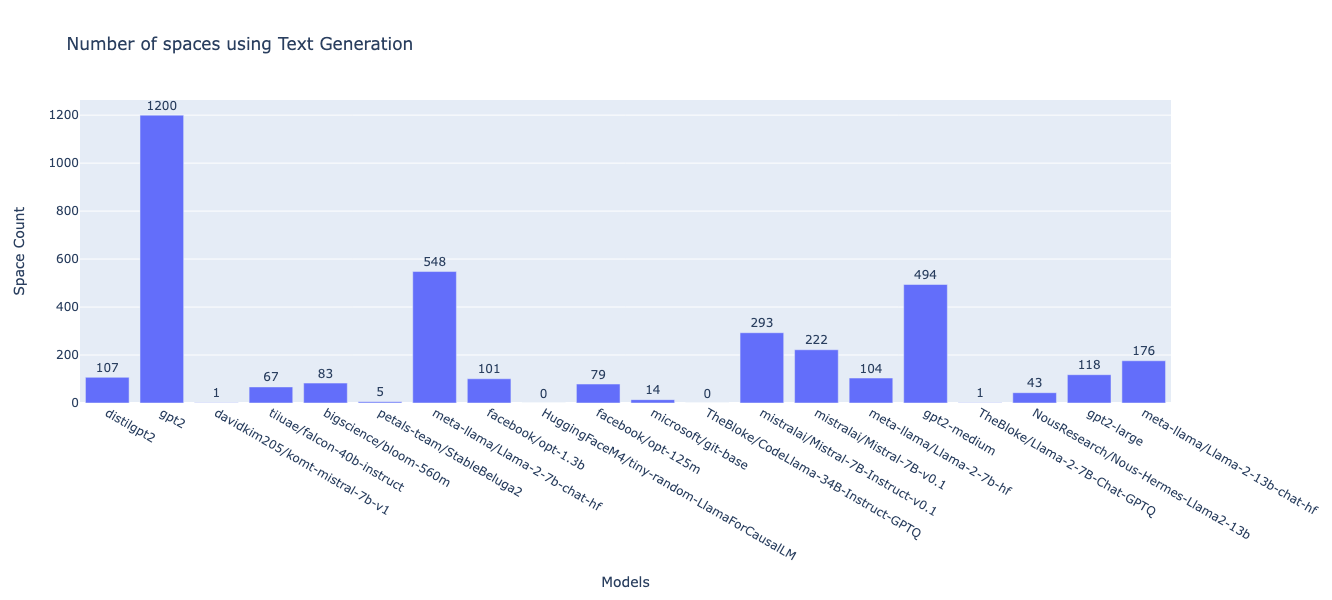

In [94]:
# convert dict for plotting the bar chart

gen_space_count = {
    "model": [],
    "count": []
}

for m, s in gen_spaces.items():
    gen_space_count["model"].append(m)
    gen_space_count["count"].append(len(s))

# from left to right, the number of downloads is decreasing, as order is preserved

fig = px.bar(
    x=gen_space_count["model"], y=gen_space_count["count"], text_auto=True,
    labels={"x": "Models", "y": "Space Count"},
    title="Number of spaces using Text Generation", height=600
)
fig.update_traces(textfont_size=12, textangle=0, textposition="outside", cliponaxis=False)
fig.show()

#### Obtain a dictionary with the specific spaces developed for each "Text Classification" model

In [10]:
cla_spaces = get_spaces(cla_model_names)

#### Display a bar chart to show the number of spaces for each "Text Classfication" model

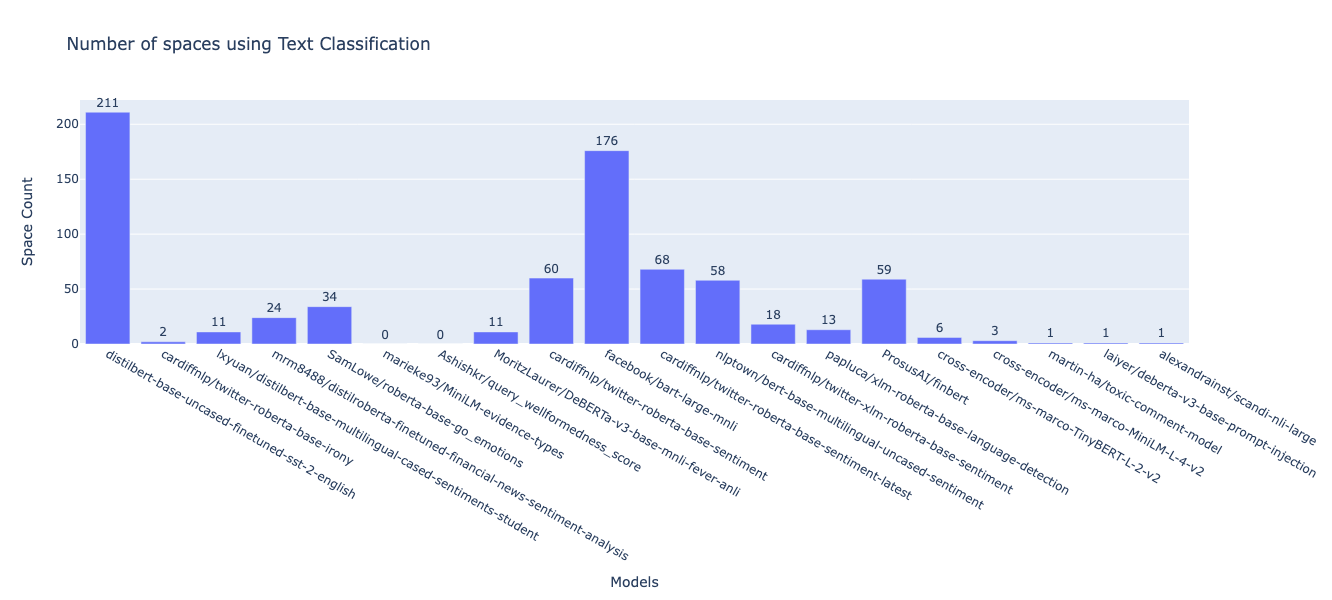

In [103]:
# convert dict for plotting the bar chart

cla_space_count = {
    "model": [],
    "count": []
}

for m, s in cla_spaces.items():
    cla_space_count["model"].append(m)
    cla_space_count["count"].append(len(s))

# from left to right, the number of downloads is decreasing, as order is preserved

fig = px.bar(
    x=cla_space_count["model"], y=cla_space_count["count"], text_auto=True,
    labels={"x": "Models", "y": "Space Count"},
    title="Number of spaces using Text Classification", height=600
)
fig.update_traces(textfont_size=12, textangle=0, textposition="outside", cliponaxis=False)
fig.show()

#### Check if the two groups of spaces are perfectly mutuall exclusive
Check if there are any spaces used both ML models from "Text-Generation" and "Text-Classification"

In [18]:
# create a list for storing overlap spaces used in both groups

space_intersection = []

for c in cla_model_names:
    for g in gen_model_names:
        intersection_list = api.list_spaces(
            models=[c, g],
            full=False
        )
        if len(list(intersection_list)) > 0:
            space_intersection.append((c, g))

space_intersection

[('distilbert-base-uncased-finetuned-sst-2-english', 'distilgpt2'),
 ('distilbert-base-uncased-finetuned-sst-2-english', 'gpt2'),
 ('distilbert-base-uncased-finetuned-sst-2-english',
  'meta-llama/Llama-2-7b-chat-hf'),
 ('distilbert-base-uncased-finetuned-sst-2-english',
  'mistralai/Mistral-7B-v0.1'),
 ('distilbert-base-uncased-finetuned-sst-2-english', 'gpt2-medium'),
 ('distilbert-base-uncased-finetuned-sst-2-english', 'gpt2-large'),
 ('facebook/bart-large-mnli', 'gpt2'),
 ('facebook/bart-large-mnli', 'gpt2-medium'),
 ('cardiffnlp/twitter-roberta-base-sentiment-latest', 'distilgpt2'),
 ('cardiffnlp/twitter-roberta-base-sentiment-latest', 'gpt2'),
 ('cross-encoder/ms-marco-TinyBERT-L-2-v2',
  'mistralai/Mistral-7B-Instruct-v0.1')]

## Check Data Distribution
### Plot a Histogram to display the distribution of the number of spaces with "Text-Generation" models
#### Result: it is not a bell-shaped curve, so data is not normally distributed

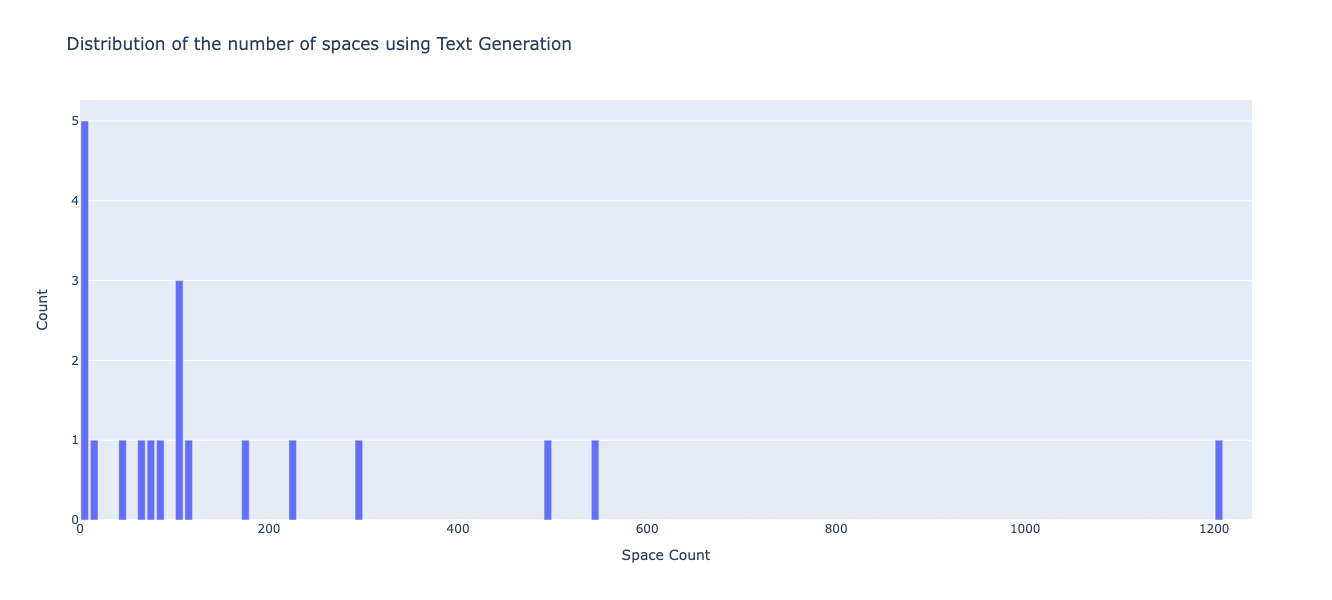

In [77]:
# create the bins to visualize the distribution of the number of space

counts, bins = np.histogram(gen_space_count["count"], bins=range(0, 1250, 10))
bins = 0.5 * (bins[: -1] + bins[1: ])

fig = px.bar(
    x=bins, y=counts, labels={"x": "Space Count", "y": "Count"},
    title="Distribution of the number of spaces using Text Generation", height=600
)
fig.show()

### Use Shapiro-Wilk test the distribution of the number of spaces with "Text-Generation" models
#### Result: p-value is significant (p < 0.05), so data is not normally distributed

In [101]:
stats.shapiro(gen_space_count["count"])

ShapiroResult(statistic=0.6474984884262085, pvalue=9.532570402370766e-06)

### Plot a Histogram to display the distribution of the number of spaces with "Text-Classification" models
#### Result: it is not a bell-shaped curve, so data is not normally distributed

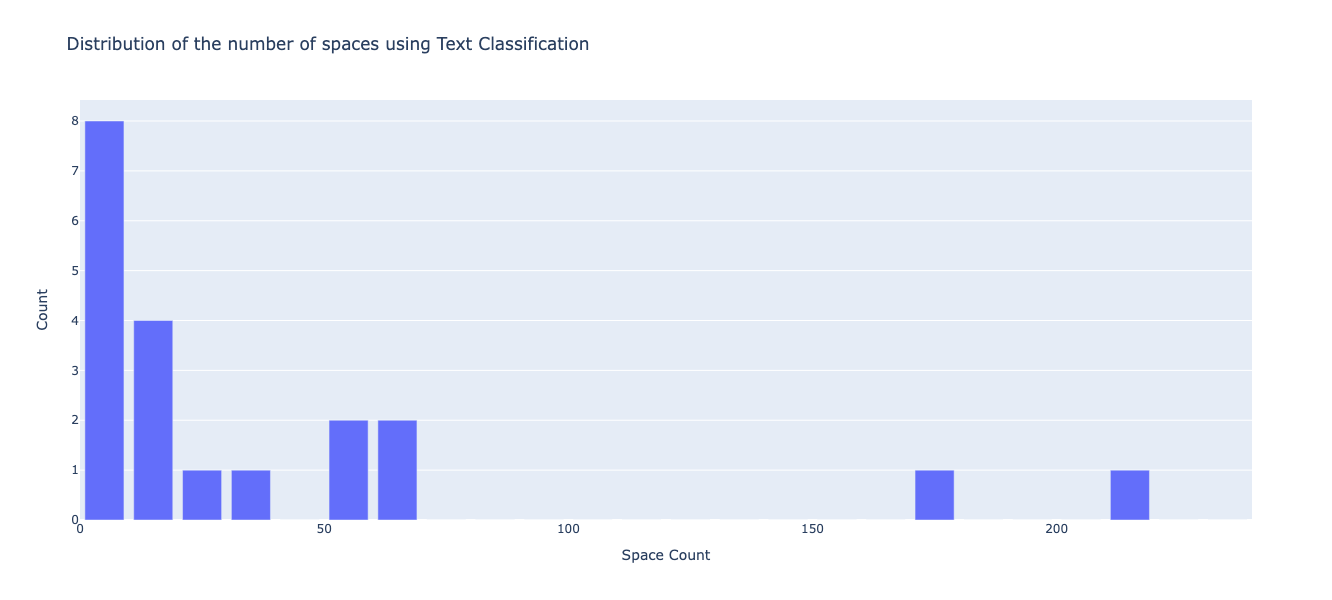

In [78]:
# create the bins to visualize the distribution of the number of space

counts, bins = np.histogram(cla_space_count["count"], bins=range(0, 250, 10))
bins = 0.5 * (bins[: -1] + bins[1: ])

fig = px.bar(
    x=bins, y=counts, labels={"x": "Space Count", "y": "Count"},
    title="Distribution of the number of spaces using Text Classification", height=600
)
fig.show()

### Use Shapiro-Wilk test the distribution of the number of spaces with "Text-Classification" models
#### Result: p-value is significant (p < 0.05), so data is not normally distributed

In [102]:
stats.shapiro(cla_space_count["count"])

ShapiroResult(statistic=0.671085000038147, pvalue=1.767103822203353e-05)

## Data Analysis - Part 2
#### Compare the total number of spaces developed using "Text Generation" models and using "Text Classification" models

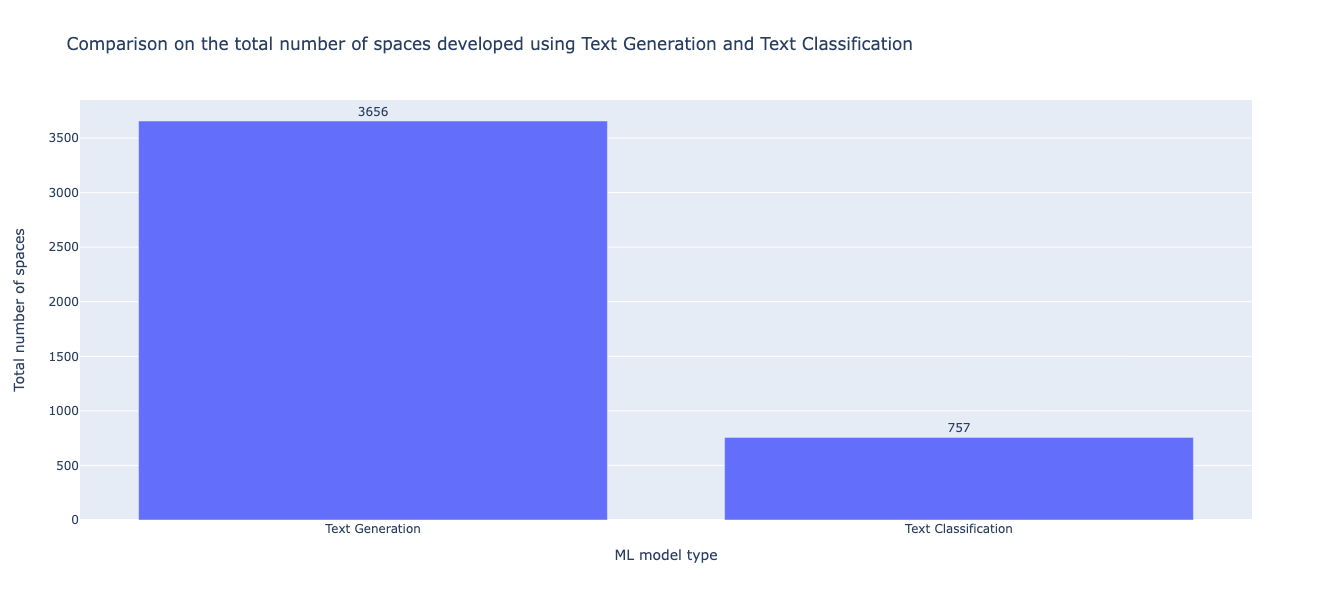

In [97]:
# get the total number of spaces developed using "Text Generation" models

total_gen_spaces = 0
for s in gen_spaces.values():
    total_gen_spaces += len(s)

# get the total number of spaces developed using "Text Classification" models

total_cla_spaces = 0
for s in cla_spaces.values():
    total_cla_spaces += len(s)

# plot a bar chart to show the difference of the total number of spaces developed using the two groups of models

total_space_count = {
    "model_type": ["Text Generation", "Text Classification"],
    "total_num_spaces": [total_gen_spaces, total_cla_spaces]
}

fig = px.bar(
    x=total_space_count["model_type"], y=total_space_count["total_num_spaces"], text_auto=True,
    labels={"x": "ML model type", "y": "Total number of spaces"},
    title="Comparison on the total number of spaces developed using Text Generation and Text Classification", height=600
)
fig.update_traces(textfont_size=12, textangle=0, textposition="outside", cliponaxis=False)
fig.show()

#### Use Mann-Whitney U test to compare the number of spaces developed using "Text Generation" models and using "Text Classification" models
#### Result: p-value obtained from the Mann-Whitney U test is significant (U = 284.5, p < 0.05), I conclude that the number of ML applications developed using "Text Generation" models is much larger than using  "Text Classification" models

In [136]:
"""
perform one-tailed test to test whether the number of ML applications 
developed using "Text Generation" models are much larger than using  "Text Classification" models
"""

stats.mannwhitneyu(
    x=gen_space_count["count"], 
    y=cla_space_count["count"], 
    alternative="greater"
)

MannwhitneyuResult(statistic=284.5, pvalue=0.011434213299653292)

## Data Collection - Part 3
Obtain and compare the source code size of the ML apps ("spaces") obtained in Part 2.

In [29]:
def get_space_size(space_id, api, included_suffix_list=None):
    """
    return each space size in bytes
    
    space_id (str): space id
    api (HfApi): hub api
    included_suffix_list (list[str] | None): file path suffix to keep, case insensitive, should all be in lower case, `None` keeps all files
    """
    total_size = 0

    for f in api.list_files_info(
        repo_id=space_id, 
        repo_type="space"
    ):
        if included_suffix_list:
            f_path = Path(f.path)
            if f_path.suffix.lower() in included_suffix_list:  # suffix is in the inclusion list
                total_size += f.size
        else:
            total_size += f.size
            
    return total_size

#### Get the total size of the source code repositories developed with "Text Generation" models

In [30]:
gen_sizes = {}

# loop through each space to check the repository size, only check files with desired suffixes

for m, s_list in gen_spaces.items():
    gen_sizes[m] = {}
    for s in s_list:
        total_size = get_space_size(s, api, [".py", ".r", ".yml", ".yaml", ".json", ".ipynb", ".java", ".m", ".sh", ".c", ".cc", ".cpp", ".jinja"])
        gen_sizes[m][s] = total_size / 1000  # convert to KB

In [31]:
gen_total_sizes = {  # for plot and stats
    "model": [],
    "size": []
}

for m, s_dict in gen_sizes.items():
    gen_total_sizes["model"].append(m)
    gen_total_sizes["size"].append(sum(s_dict.values()))

#### Get the total size of the source code repositories developed with "Text Classification" models

In [42]:
cla_sizes = {}

# loop through each space to check the repository size, only check files with desired suffixes

for m, s_list in cla_spaces.items():
    cla_sizes[m] = {}
    for s in s_list:
        total_size = get_space_size(s, api, [".py", ".r", ".yml", ".yaml", ".json", ".ipynb", ".java", ".m", ".sh", ".c", ".cc", ".cpp", ".jinja"])
        cla_sizes[m][s] = total_size / 1000  # convert to KB

In [43]:
cla_total_sizes = {  # for plot and stats
    "model": [],
    "size": []
}

for m, s_dict in cla_sizes.items():
    cla_total_sizes["model"].append(m)
    cla_total_sizes["size"].append(sum(s_dict.values()))

## Check Data Distribution
### Plot a Histogram to display the distribution of the source size of spaces with "Text-Generation" models
#### Result: it is not a bell-shaped curve, so data is not normally distributed

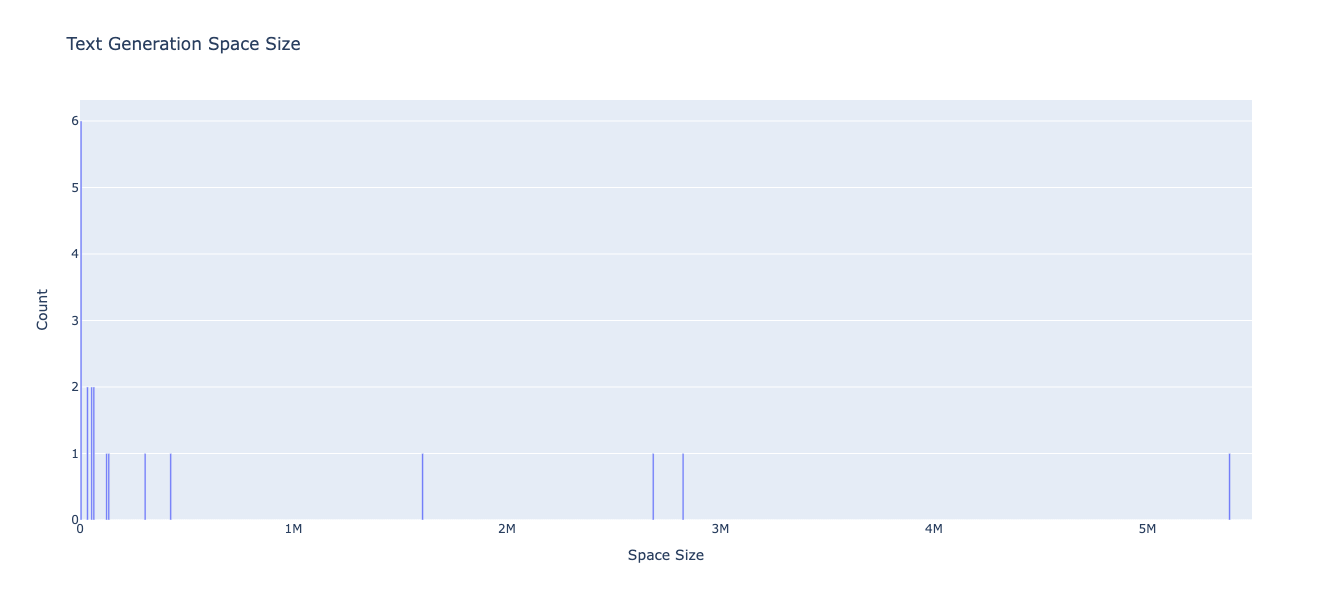

In [104]:
counts, bins = np.histogram(gen_total_sizes["size"], bins=range(0, 5500000, 10000))
bins = 0.5 * (bins[: -1] + bins[1: ])

fig = px.bar(
    x=bins, y=counts, labels={"x": "Space Size", "y": "Count"},
    title="Text Generation Space Size", height=600
)
fig.show()

### Use Shapiro-Wilk test the distribution of the number of spaces with "Text-Generation" models
#### Result: p-value is significant (p < 0.05), so data is not normally distributed

In [105]:
stats.shapiro(gen_total_sizes["size"])

ShapiroResult(statistic=0.5656806826591492, pvalue=1.3251257087176782e-06)

### Plot a Histogram to display the distribution of the source size of spaces with "Text-Classification" models
#### Result: it is not a bell-shaped curve, so data is not normally distributed

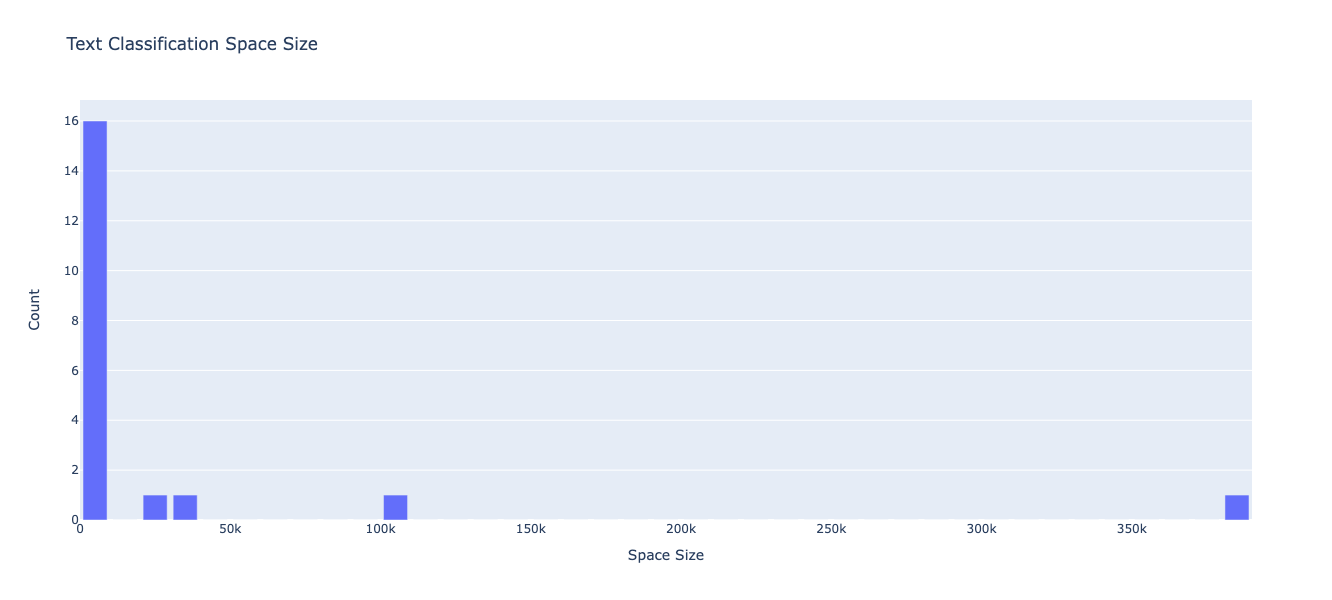

In [54]:
counts, bins = np.histogram(cla_total_sizes["size"], bins=range(0, 400000, 10000))
bins = 0.5 * (bins[: -1] + bins[1: ])

fig = px.bar(
    x=bins, y=counts, labels={"x": "Space Size", "y": "Count"},
    title="Text Classification Space Size", height=600
)
fig.show()

### Use Shapiro-Wilk test the distribution of the number of spaces with "Text-Classification" models
#### Result: p-value is significant (p < 0.05), so data is not normally distributed

In [99]:
stats.shapiro(cla_total_sizes["size"])

ShapiroResult(statistic=0.37158942222595215, pvalue=2.6535021291351768e-08)

## Data Analysis - Part 3
#### Compare the average source code size of spaces developed using "Text Generation" models and using "Text Classification" models

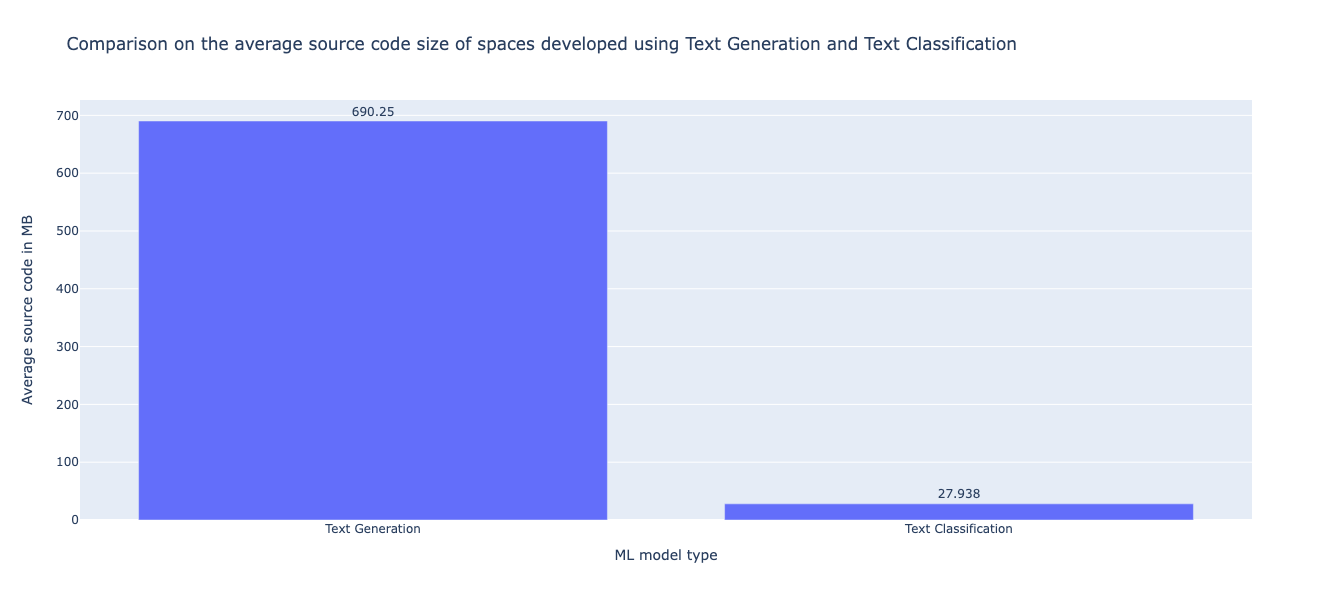

In [108]:
# get the average source code size of spaces for each group, convert to MB for better display purpose

avg_gen_spaces = np.mean(gen_total_sizes["size"]) / 1000
avg_cla_spaces = np.mean(cla_total_sizes["size"]) / 1000

# plot a bar chart to show the difference of the average source code size of spaces using the two groups of models

total_space_count = {
    "model_type": ["Text Generation", "Text Classification"],
    "avg_size": [avg_gen_spaces, avg_cla_spaces]
}

fig = px.bar(
    x=total_space_count["model_type"], y=total_space_count["avg_size"], text_auto=".5s",
    labels={"x": "ML model type", "y": "Average source code in MB"},
    title="Comparison on the average source code size of spaces developed using Text Generation and Text Classification", height=600
)
fig.update_traces(textfont_size=12, textangle=0, textposition="outside", cliponaxis=False)
fig.show()

#### Use Mann-Whitney U test to compare the source code size of spaces developed using "Text Generation" models and using "Text Classification" models
#### Result: p-value obtained from the Mann-Whitney U test is significant (U = 304, p < 0.05), I conclude that the source code size of ML applications developed using "Text Generation" models is much larger than using "Text Classification" models

In [93]:
"""
perform one-tailed test to test whether the source code size of ML applications 
developed using "Text Generation" models is much larger than using "Text Classification" models
"""

stats.mannwhitneyu(
    x=gen_total_sizes["size"], 
    y=cla_total_sizes["size"], 
    alternative="greater"
)

MannwhitneyuResult(statistic=304.0, pvalue=0.0025472392677000147)